# Decision Tree Classifier on Brainvita (From Scratch)

This notebook trains the custom `rice_ml.supervised_learning.DecisionTreeClassifier` on a binary Brainvita mobility label: `num_legal_moves >= 3`.

A decision tree is useful here because Brainvita mobility is not necessarily linear. The model can learn threshold rules such as "if jumpable pegs is high and cluster count is low, predict high mobility." The notebook builds that idea step by step: define the impurity criterion, load the same curated Brainvita features, compare against a majority-class baseline, fit a single tree, inspect metrics, and examine probability separation.

## Learning Objectives

1. Explain how a CART-style classifier uses Gini impurity to choose splits.
2. Frame Brainvita high mobility as a binary classification target.
3. Compare a majority-class baseline against a single decision tree.
4. Evaluate accuracy, precision, recall, F1, and confusion matrices.
5. Interpret the probability histogram as a diagnostic for class separation and overconfident leaves.


## Dataset and Target

We use the same Brainvita feature matrix as the other notebooks so model comparisons are meaningful. The target is binary: class 1 means the state has at least three legal moves, and class 0 means it has fewer than three.

Trees do not need feature standardization because split rules compare one feature at a time. Keeping raw feature units also makes threshold logic easier to interpret.

## 1. Mathematical Intuition

Decision trees recursively split data by feature-threshold rules to reduce impurity.

For classification, your implementation uses **Gini impurity**:

$$
G = 1 - \sum_k p_k^2
$$

At each node, the tree selects the split with lowest weighted child impurity.


In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt


def find_repo_root(start='.'):
    p = Path(start).resolve()
    for q in [p, *p.parents]:
        if (q / 'src' / 'rice_ml').exists() and (q / 'data' / 'brainvita_dataset.csv').exists():
            return q
    raise FileNotFoundError('Could not locate repository root')


ROOT = find_repo_root('.')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

DATA_PATH = ROOT / 'data' / 'brainvita_dataset.csv'
print('Repo root:', ROOT)
print('Dataset path:', DATA_PATH)

from rice_ml.supervised_learning import DecisionTreeClassifier

Repo root: /Users/LakshSarda/Desktop/CMOR_438_Repository
Dataset path: /Users/LakshSarda/Desktop/CMOR_438_Repository/data/brainvita_dataset.csv


The setup output has two parts. The Matplotlib font-cache message is environmental and does not describe the model. The repository root and dataset path confirm that the notebook is reading from the expected local repository and `data/brainvita_dataset.csv` before any sampling, fitting, or evaluation happens.

In [2]:
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    header = f.readline().strip().split(',')

exclude_cols = {
    'num_legal_moves',
    'board_state',
    'best_move_r1', 'best_move_c1', 'best_move_r2', 'best_move_c2',
    'worst_move_r1', 'worst_move_c1', 'worst_move_r2', 'worst_move_c2',
}

raw_feature_cols = [c for c in header if c not in exclude_cols]
selected_cols = raw_feature_cols + ['num_legal_moves']
selected_idx = [header.index(c) for c in selected_cols]
arr = np.loadtxt(DATA_PATH, delimiter=',', skiprows=1, usecols=selected_idx, dtype=float)

X_raw = arr[:, :-1]
y_reg = arr[:, -1]
y_bin = (y_reg >= 3.0).astype(int)

preferred_features = ['peg_ratio', 'jumpable_pegs', 'mobility_ratio', 'num_clusters', 'largest_cluster', 'avg_adjacent_pegs', 'avg_adjacent_empty', 'max_adjacent_empty', 'center_of_mass_r', 'center_of_mass_c', 'spread', 'min_pegs_reachable', 'max_pegs_reachable', 'board_rows', 'board_cols']
feature_cols = [c for c in preferred_features if c in raw_feature_cols]
keep_idx = [raw_feature_cols.index(c) for c in feature_cols]
X = X_raw[:, keep_idx]

# Reproducible subset for notebook runtime while preserving methodology.
rng_sample = np.random.default_rng(42)
sample_n = min(12000, X.shape[0])
sel = rng_sample.choice(X.shape[0], size=sample_n, replace=False)
X = X[sel]
y_reg = y_reg[sel]
y_bin = y_bin[sel]
print('Using sampled rows for notebook execution:', X.shape[0])

print(f'Rows: {X.shape[0]:,} | Features: {X.shape[1]}')
print('Positive class rate (num_legal_moves >= 3):', float(y_bin.mean()))
print('Features used:', feature_cols)

y_target = y_bin

Using sampled rows for notebook execution: 12000
Rows: 12,000 | Features: 15
Positive class rate (num_legal_moves >= 3): 0.28675
Features used: ['peg_ratio', 'jumpable_pegs', 'mobility_ratio', 'num_clusters', 'largest_cluster', 'avg_adjacent_pegs', 'avg_adjacent_empty', 'max_adjacent_empty', 'center_of_mass_r', 'center_of_mass_c', 'spread', 'min_pegs_reachable', 'max_pegs_reachable', 'board_rows', 'board_cols']


The loading output confirms that this notebook intentionally uses a 12,000-row sample rather than the full dataset. It keeps the same 15 engineered features and reports a positive-class rate of `0.28675`, so high-mobility states are still the minority class in this sampled version.

The sample size matters for interpretation. The later tree metrics describe performance on this 12,000-row sampled workflow, not on all 238,486 original rows. The feature list confirms that the tree is still using interpretable board summaries rather than raw board strings or move-coordinate labels.

## 2. Split Data (No Scaling Needed)

The split is shuffled with a fixed random seed for reproducibility. Unlike logistic regression, perceptron, MLP, or KNN, we do not standardize the features: a decision tree only asks whether a feature is below or above a threshold, so feature scale does not distort the model.

In [3]:
rng = np.random.default_rng(42)
idx = np.arange(X.shape[0])
rng.shuffle(idx)

split = int(0.8 * len(idx))
train_idx, test_idx = idx[:split], idx[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y_target[train_idx], y_target[test_idx]

print('Train samples:', X_train.shape[0], '| Test samples:', X_test.shape[0])


Train samples: 9600 | Test samples: 2400


The split output confirms 9,600 training samples and 2,400 test samples from the 12,000-row sample. This is the held-out evaluation scale for the metrics below.

Unlike the linear, logistic, perceptron, and MLP notebooks, this tree notebook does not need standardized features for fitting. The output confirms the split size; the modeling choice is that threshold-based tree splits can operate directly on the feature values.

## 3. Train Tree and Compare Baselines

The majority-class baseline shows what accuracy looks like if we ignore every feature. The tree should beat that baseline and should also keep train/test metrics reasonably close. If training accuracy is much higher than test accuracy, the tree is too deep or the leaf sizes are too small.

In [4]:
model = DecisionTreeClassifier(max_depth=8, min_samples_split=8, min_samples_leaf=4, random_state=42)
model.fit(X_train, y_train)
print('Model:', model.__class__.__name__)
print('Classes:', model.classes_)
print('n_features_in_:', model.n_features_in_)


Model: DecisionTreeClassifier
Classes: [0 1]
n_features_in_: 15


The model-identification output confirms that the fitted object is a `DecisionTreeClassifier`, that it learned classes `[0, 1]`, and that it received 15 input features. This lines up with the feature list printed earlier, so the classifier is using the intended engineered board summaries.

This cell does not report performance yet. Its value is a sanity check before evaluation: the tree was fit successfully, recognized the binary labels, and did not silently change the feature count.

In [5]:
def classification_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)

    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))

    acc = float(np.mean(y_true == y_pred))
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {'acc': acc, 'precision': precision, 'recall': recall, 'f1': f1, 'cm': np.array([[tn, fp], [fn, tp]])}

majority_class = int(np.bincount(y_train).argmax())
majority_pred = np.full_like(y_test, majority_class)
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

rows = [
    ('Majority baseline', classification_metrics(y_test, majority_pred)),
    ('Tree train', classification_metrics(y_train, y_pred_train)),
    ('Tree test', classification_metrics(y_test, y_pred_test)),
]

print('Decision tree comparison')
print('-' * 90)
print(f"{'Model':<22}{'Acc':>10}{'Precision':>12}{'Recall':>12}{'F1':>12}")
print('-' * 90)
for name, metrics in rows:
    print(f"{name:<22}{metrics['acc']:>10.4f}{metrics['precision']:>12.4f}{metrics['recall']:>12.4f}{metrics['f1']:>12.4f}")
print('-' * 90)

print('Test confusion matrix [ [TN, FP], [FN, TP] ]')
print(rows[-1][1]['cm'])


Decision tree comparison
------------------------------------------------------------------------------------------
Model                        Acc   Precision      Recall          F1
------------------------------------------------------------------------------------------
Majority baseline         0.7229      0.0000      0.0000      0.0000
Tree train                0.9928      1.0000      0.9751      0.9874
Tree test                 0.9933      1.0000      0.9759      0.9878
------------------------------------------------------------------------------------------
Test confusion matrix [ [TN, FP], [FN, TP] ]
[[1735    0]
 [  16  649]]


The comparison table shows why the majority baseline is not a serious model for this task. It reaches accuracy `0.7229` only because class 0 is more common in the sampled test set, but its precision, recall, and F1 are all `0.0000` because it never predicts the high-mobility class.

The fitted tree performs very differently. On the test set it reaches accuracy `0.9933`, precision `1.0000`, recall `0.9759`, and F1 `0.9878`. The confusion matrix explains those metrics: 1,735 true negatives, 0 false positives, 16 false negatives, and 649 true positives. The zero false positives are why precision is exactly 1.0, while the 16 missed positive states are why recall is below 1.0.

The train and test rows are also close. Train F1 is `0.9874`, and test F1 is `0.9878`. In this particular run, the sampled test result is not worse than the training result, so the output does not show a visible overfitting gap for the chosen depth and leaf-size settings.

## 4. Probability Calibration Snapshot

`predict_proba` reports the class mixture in the reached leaf. This is not calibrated in the same way as logistic regression probability, but the histogram still helps: good separation means class-1 states tend to receive high probabilities and class-0 states tend to receive low probabilities. Many probabilities near 0 or 1 can also indicate overconfident small leaves.

The next plot should be read as a diagnostic, not as a formal calibration curve. We want the two class histograms to separate, while remembering that each probability comes from a leaf frequency.

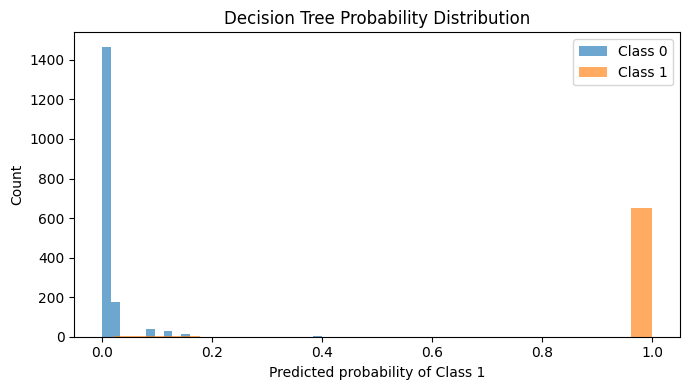

In [6]:
proba = model.predict_proba(X_test)[:, 1]
plt.figure(figsize=(7, 4))
plt.hist(proba[y_test == 0], bins=25, alpha=0.65, label='Class 0')
plt.hist(proba[y_test == 1], bins=25, alpha=0.65, label='Class 1')
plt.xlabel('Predicted probability of Class 1')
plt.ylabel('Count')
plt.title('Decision Tree Probability Distribution')
plt.legend()
plt.tight_layout()
plt.show()


The probability histogram is sharply separated. Most class 0 examples are concentrated near probability 0, while most class 1 examples are concentrated near probability 1. This matches the confusion matrix: the tree rarely confuses the two classes on this sampled test set.

The few small blue bars away from zero show that some low-mobility states receive nonzero positive-class probability, even though the thresholded classifier makes no false positives at the default threshold. The orange mass near 1.0 shows that most high-mobility states are assigned high positive-class probability, but the earlier confusion matrix still records 16 missed positives, so the separation is strong rather than perfect.

This plot should not be described as formal calibration. A decision tree's probability comes from the class mix inside a leaf, so the spikes near 0 and 1 mostly show that the fitted leaves are very pure on this test split.

## 5. Conclusion

The decision tree is a strong nonlinear classifier on the sampled Brainvita task. Its test accuracy is `0.9933`, test precision is `1.0000`, test recall is `0.9759`, and test F1 is `0.9878`. Those numbers are far above the majority baseline, which has F1 `0.0000` because it never predicts a high-mobility state.

The confusion matrix gives the most concrete interpretation: the tree makes no false-positive predictions on this test split, correctly identifies 649 high-mobility states, and misses 16 high-mobility states. That is excellent performance, but not perfect recall.

The probability histogram supports the same conclusion visually. Most low-mobility states sit near predicted probability 0, and most high-mobility states sit near predicted probability 1. The caveat is that decision-tree probabilities are leaf frequencies, not guaranteed calibrated probabilities, and this notebook used a 12,000-row sample rather than the full dataset.
